# Cafe Sales Data Cleaning Project

## Objective
Clean a real-world messy cafe sales dataset containing 10,000 transactions 
with multiple data quality issues including missing values, dirty entries, 
wrong data types and inconsistent formats.

## Dataset
- Source: Kaggle — Cafe Sales Dirty Data for Cleaning Training
- Shape: 10,000 rows × 8 columns
- File: cafe_sales.csv

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Load Dataset

In [3]:
dataset=pd.read_csv("dirty_cafe_sales.csv")
df_before = dataset.copy()  # original saved for comparison
dataset.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


## Explore Shape and Structure

In [7]:
dataset.shape

(10000, 8)

In [8]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    10000 non-null  str  
 1   Item              9667 non-null   str  
 2   Quantity          9862 non-null   str  
 3   Price Per Unit    9821 non-null   str  
 4   Total Spent       9827 non-null   str  
 5   Payment Method    7421 non-null   str  
 6   Location          6735 non-null   str  
 7   Transaction Date  9841 non-null   str  
dtypes: str(8)
memory usage: 1.1 MB


##  Check Missing Values
Missing values ranked from worst to best.
Location and Payment Method are most affected.

In [9]:
missing_count=((dataset.isnull().sum())/len(dataset))*100
missing_count


Transaction ID       0.00
Item                 3.33
Quantity             1.38
Price Per Unit       1.79
Total Spent          1.73
Payment Method      25.79
Location            32.65
Transaction Date     1.59
dtype: float64

In [10]:
missing_percent=((missing_count.sum())/dataset.size)*100
missing_percent

np.float64(0.08532500000000001)

In [11]:
print(missing_count.sort_values(ascending=False))

Location            32.65
Payment Method      25.79
Item                 3.33
Price Per Unit       1.79
Total Spent          1.73
Transaction Date     1.59
Quantity             1.38
Transaction ID       0.00
dtype: float64


## Check Duplicates

In [12]:
dataset.duplicated().sum()

np.int64(0)

## Check Data Types
All columns loaded as string. 
Quantity, Price Per Unit, Total Spent should be numeric.
Transaction Date should be datetime.

In [13]:
dataset.dtypes

Transaction ID      str
Item                str
Quantity            str
Price Per Unit      str
Total Spent         str
Payment Method      str
Location            str
Transaction Date    str
dtype: object

##  Check Dirty Values
Checking what invalid values exist inside numeric columns.

In [14]:
print(dataset['Quantity'].unique())
print(dataset['Price Per Unit'].unique())
print(dataset['Total Spent'].unique())
print(dataset['Location'].value_counts())

<ArrowStringArray>
['2', '4', '5', '3', '1', 'ERROR', 'UNKNOWN', nan]
Length: 8, dtype: str
<ArrowStringArray>
['2.0', '3.0', '1.0', '5.0', '4.0', '1.5', nan, 'ERROR', 'UNKNOWN']
Length: 9, dtype: str
<ArrowStringArray>
[    '4.0',    '12.0',   'ERROR',    '10.0',    '20.0',     '9.0',    '16.0',
    '15.0',    '25.0',     '8.0',     '5.0',     '3.0',     '6.0',       nan,
 'UNKNOWN',     '2.0',     '1.0',     '7.5',     '4.5',     '1.5']
Length: 20, dtype: str
Location
Takeaway    3022
In-store    3017
ERROR        358
UNKNOWN      338
Name: count, dtype: int64


In [6]:
print("\nERROR count:", (dataset == 'ERROR').sum().sum())
print("UNKNOWN count:", (dataset == 'UNKNOWN').sum().sum())


ERROR count: 956
UNKNOWN count: 975


## Data Cleaning

###  Replace ERROR and UNKNOWN with NaN
Must do this BEFORE type conversion otherwise conversion will crash.

In [15]:
dataset.replace({'ERROR': np.nan, 'UNKNOWN': np.nan}, inplace=True)
dataset.head(10)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,NaN,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,NaN,NaN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,Smoothie,5,4.0,20.0,Credit Card,NaN,2023-03-31
6,TXN_4433211,NaN,3,3.0,9.0,NaN,Takeaway,2023-10-06
7,TXN_6699534,Sandwich,4,4.0,16.0,Cash,NaN,2023-10-28
8,TXN_4717867,NaN,5,3.0,15.0,NaN,Takeaway,2023-07-28
9,TXN_2064365,Sandwich,5,4.0,20.0,NaN,In-store,2023-12-31


### Data types fixing

In [4]:
dataset['Quantity'] = pd.to_numeric(dataset['Quantity'], errors='coerce')
dataset['Price Per Unit'] = pd.to_numeric(dataset['Price Per Unit'], errors='coerce')
dataset['Total Spent'] = pd.to_numeric(dataset['Total Spent'], errors='coerce')
dataset['Transaction Date'] = pd.to_datetime(dataset['Transaction Date'], errors='coerce')

### Handling missining values

Location   ----->   39.61

Payment Method ----->    31.78

Item            ---->     9.69

Price Per Unit  ---->     5.33

Total Spent   ---->       5.02

Quantity        ---->     4.79

Transaction Date ---->    4.60

Transaction ID   ---->    0.00


Strategy:
- Location → fill with 'unknown' (no meaningful value to impute)
- Payment Method → fill with 'unknown' (no meaningful value to impute)  
- Quantity → fill with median (numeric, robust to outliers)
- Price Per Unit → fill with median (numeric, robust to outliers)
- Item → fill with mode (categorical, most frequent)
- Transaction Date → forward fill (date sequence makes sense)

In [5]:
dataset['Location'] = dataset['Location'].fillna('unknown')
dataset['Payment Method'] = dataset['Payment Method'].fillna('unknown')

dataset['Quantity'] = dataset['Quantity'].fillna(dataset['Quantity'].median())
dataset['Price Per Unit'] = dataset['Price Per Unit'].fillna(dataset['Price Per Unit'].median())
dataset['Item'] = dataset['Item'].fillna(dataset['Item'].mode()[0])
dataset['Transaction Date'] = dataset['Transaction Date'].ffill()

### Recalculate Total Spent
Total Spent had dirty values. Instead of guessing,
recalculate directly from Quantity × Price Per Unit.
This guarantees mathematical consistency.

In [10]:
dataset["Total Spent"]=dataset["Quantity"]*dataset["Price Per Unit"]

### Clean Text Format
Standardize all text columns to lowercase and strip whitespace.
Prevents duplicates like 'Coffee' and 'coffee' being treated differently.

In [11]:
dataset['Item'] = dataset['Item'].str.lower().str.strip()
dataset['Location'] = dataset['Location'].str.lower().str.strip()
dataset['Payment Method'] = dataset['Payment Method'].str.lower().str.strip()

### Validate Data
Verify Total Spent = Quantity × Price Per Unit for all rows.
Result should be 0.0 meaning no inconsistencies remain.

In [12]:
((dataset['Quantity'] * dataset['Price Per Unit']) - dataset['Total Spent']).sum()

np.float64(0.0)

In [13]:
dataset.to_csv("cleaned_cafe_sales.csv", index=False)

###  Extract Date Features
Extract Month, Day, Year, Day of Week and Month Name
for future time-based analysis.

In [14]:



dataset['Month'] = dataset['Transaction Date'].dt.month
dataset['Day'] = dataset['Transaction Date'].dt.day
dataset['Year'] = dataset['Transaction Date'].dt.year
dataset['Day_of_Week'] = dataset['Transaction Date'].dt.day_name()
dataset['Month_Name'] = dataset['Transaction Date'].dt.month_name()


dataset[['Transaction Date', 'Year', 'Month', 'Month_Name', 'Day', 'Day_of_Week']].head()

,Transaction Date,Year,Month,Month_Name,Day,Day_of_Week
0,2023-09-08,2023,9,September,8,Friday
1,2023-05-16,2023,5,May,16,Tuesday
2,2023-07-19,2023,7,July,19,Wednesday
3,2023-04-27,2023,4,April,27,Thursday
4,2023-06-11,2023,6,June,11,Sunday


## Before and After Comparison

In [15]:
df_before = pd.read_csv('dirty_cafe_sales.csv')
df_after = pd.read_csv('cleaned_cafe_sales.csv')

In [16]:
df_after['Transaction Date'] = pd.to_datetime(df_after['Transaction Date'])

### Shape

In [17]:
print(f"Before: {df_before.shape}")
print(f"After:  {df_after.shape}")

Before: (10000, 8)
After:  (10000, 8)


### MIssing Values

In [18]:
print("BEFORE:")
print((df_before.isnull().sum() / len(df_before) * 100).sort_values(ascending=False))

print("\nAFTER:")
print((df_after.isnull().sum() / len(df_after) * 100).sort_values(ascending=False))

BEFORE:
Location            32.65
Payment Method      25.79
Item                 3.33
Price Per Unit       1.79
Total Spent          1.73
Transaction Date     1.59
Quantity             1.38
Transaction ID       0.00
dtype: float64

AFTER:
Transaction ID      0.0
Item                0.0
Quantity            0.0
Price Per Unit      0.0
Total Spent         0.0
Payment Method      0.0
Location            0.0
Transaction Date    0.0
dtype: float64


### Dirty Values

In [19]:
print("ERROR before:", (df_before == 'ERROR').sum().sum())
print("UNKNOWN before:", (df_before == 'UNKNOWN').sum().sum())
print("ERROR after:", (df_after == 'ERROR').sum().sum())
print("UNKNOWN after:", (df_after == 'UNKNOWN').sum().sum())

ERROR before: 1622
UNKNOWN before: 1634
ERROR after: 0
UNKNOWN after: 0


### Data Types

In [20]:
comparison = pd.DataFrame({
    'Before': df_before.dtypes,
    'After': df_after.dtypes
})
print(comparison)

                 Before           After
Transaction ID      str             str
Item                str             str
Quantity            str         float64
Price Per Unit      str         float64
Total Spent         str         float64
Payment Method      str             str
Location            str             str
Transaction Date    str  datetime64[us]


## Before vs After Comparison

Visualizing the impact of cleaning on missing values across all columns.

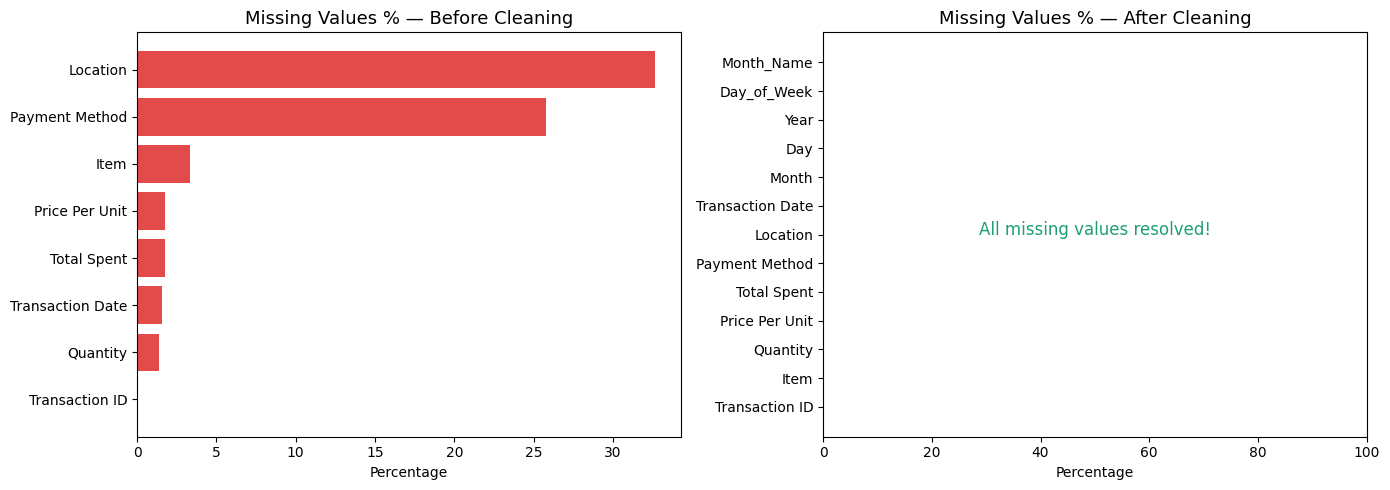

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# before
missing_before = (df_before.isnull().sum() / len(df_before) * 100).sort_values(ascending=True)
axes[0].barh(missing_before.index, missing_before.values, color='#E24B4A')
axes[0].set_title('Missing Values % — Before Cleaning', fontsize=13)
axes[0].set_xlabel('Percentage')

# after
axes[1].barh(missing_after.index, missing_after.values, color='#1D9E75')
axes[1].set_title('Missing Values % — After Cleaning', fontsize=13)
axes[1].set_xlabel('Percentage')
axes[1].set_xlim(0, 100)
axes[1].text(50, 6, 'All missing values resolved!', 
             fontsize=12, color='#1D9E75', ha='center')

plt.tight_layout()
plt.show()

## Data Cleaning Summary — Cafe Sales Dataset

### Dataset Overview
| | Before | After |
|---|---|---|
| Rows | 10,000 | 10,000 |
| Columns | 8 | 13 |
| New columns added | — | Month, Day, Year ,Day_of_Week, Month_Name|
### Missing Values Handled
| Column | Before | After |
|---|---|---|
| Location | 32.65% | 0% |
| Payment Method | 25.79% | 0% |
| Item | 3.33% | 0% |
| Price Per Unit | 1.79% | 0% |
| Total Spent | 1.73% | 0% |
| Transaction Date | 1.59% | 0% |
| Quantity | 1.38% | 0% |
| Transaction ID | 0.00% | 0% |

### Dirty Values Removed
| Value | Before | After |
|---|---|---|
| ERROR | 1,622 | 0 |
| UNKNOWN | 1,634 | 0 |
| Total dirty values | 3,256 | 0 |

### Data Types Fixed
| Column | Before | After |
|---|---|---|
| Quantity | string | float64 |
| Price Per Unit | string | float64 |
| Total Spent | string | float64 |
| Month | did not exist | int64 |
| Day | did not exist | int64 |
| Year | did not exist | int64 |
| Day_of_Week | did not exist |str|
| Month-Name | did not exist |str|

### New Features Extracted from Transaction Date
| New Column | Description |
|---|---|
| Month | Month number (1–12) |
| Month_Name | Month name (January, February...) |
| Day | Day of month (1–31) |
| Day_of_Week | Day name (Monday, Tuesday...) |
| Year | Year (2023, 2024...) |

### Decisions Made
| Column | Strategy |
|---|---|
| Location | Filled missing with 'Unknown' |
| Payment Method | Filled missing with 'Unknown' |
| Numeric columns | Filled missing with median |
| Categorical columns | Filled missing with mode |
| ERROR / UNKNOWN | Replaced with NaN then filled |
| Transaction Date | Extracted Month, Day, Year |
| Transaction Date | Converted to datetime, extracted 5 new features |